# 1. Date Feature Engineering 

In [8]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt


In [4]:
df=pd.read_csv('F:\masai_notes\Assignmnt_4a_4b_ML\data\q3_retail_promotions.csv')

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Create month-end feature
day_values = df['transaction_date'].dt.day      # Extract day of month

# Apply condition to check if day >= 25
is_month_end_values = []

for day in day_values:
    if day >= 25:
        is_month_end_values.append(1)
    else:
        is_month_end_values.append(0)

# Assign to new column
df['is_month_end'] = is_month_end_values

# Display sample
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


# 2. Temporal Train-Test Split

In [ ]:
# Sort by date
df = df.sort_values(by='transaction_date')      #---> Sort data by transaction date

# Calculate split index
split_index = int(0.8 * len(df))        #---> Calculate index for 80% split

# Split data
train_data = df.iloc[:split_index]      #---> Training data (first 80%)
test_data = df.iloc[split_index:]      #---> Testing data (remaining 20%)

###  A random split is not suitable for time-based data because it mixes old and new data. This can make the model learn from future data, which is not realistic. A temporal split keeps past data for training and future data for testing, which gives more accurate results.

# 3. Preprocessing Pipeline

In [7]:

# Split features and target
X_train = train_data.drop(columns='items_sold')
y_train = train_data['items_sold']

X_test = test_data.drop(columns='items_sold')
y_test = test_data['items_sold']

# Column types
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Preprocessing
preprocessor = ColumnTransformer( transformers=[ ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols), ('num', StandardScaler(), numerical_cols)])

# Pipeline
pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor)])

# Fit and transform
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

# Model Training and Evaluation

Linear Regression RMSE: 27.11258949801819
Linear Regression MAE: 21.011454141126492
Random Forest RMSE: 30.88270138152715
Random Forest MAE: 24.41792098214286


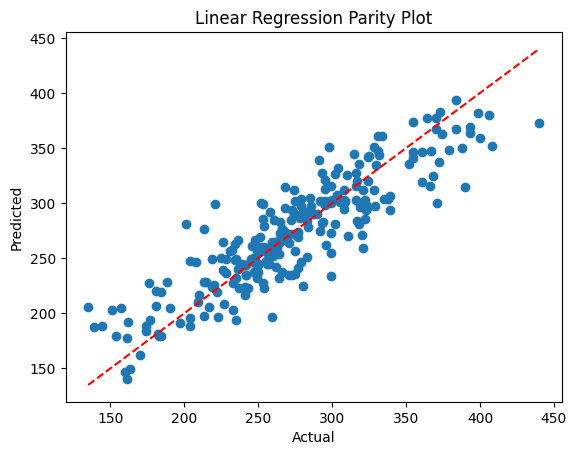

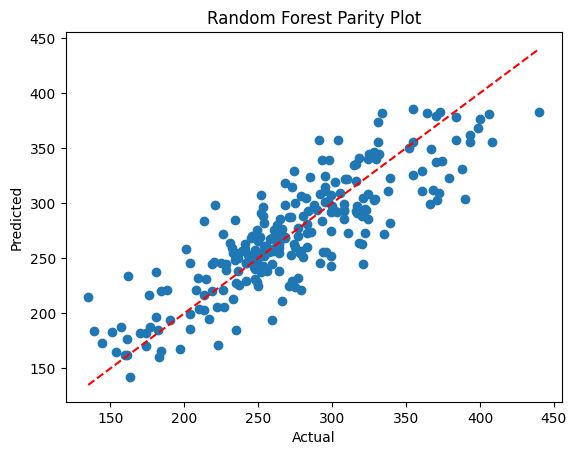

                     Feature  Importance
13          num__is_festival    0.173809
10     cat__store_size_small    0.167119
12           num__is_weekend    0.128554
7   cat__location_type_urban    0.109729
11             num__store_id    0.089050


In [9]:
# Linear Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

#Train models
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Predictions

y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)



# Evaluation

# Linear Regression
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

# Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)


# Linear Regression Plot
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression Parity Plot")
plt.show()

# Random Forest Plot
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Parity Plot")
plt.show()

# Get feature names after preprocessing
feature_names = rf_pipeline.named_steps['preprocessing'].get_feature_names_out()

# Get importances
importances = rf_pipeline.named_steps['model'].feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Top 5 features
print(feature_importance_df.head(5))